<a href="https://colab.research.google.com/github/ozerovamarina-dot/-/blob/main/%D0%A5%D0%BB%D1%8B%D0%B7%D0%BE%D0%B2%D0%B0_%D0%9C%D0%A2_%D0%9F%D0%A03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Flatten, Dropout
from tensorflow.keras import utils
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

max_words=10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_words)

word_index = imdb.get_word_index()
reverse_word_index = dict()
for key, value in word_index.items():
    reverse_word_index[value] = key

maxlen = 200
x_train = pad_sequences(x_train, maxlen=maxlen, padding='post')
x_test = pad_sequences(x_test, maxlen=maxlen, padding='post')

# создание нейронной сети
model = Sequential()
model.add(Embedding(max_words, 2, input_length=maxlen))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# обучение нейронной сети
history = model.fit(x_train,
                    y_train,
                    epochs=15,
                    batch_size=128,
                    validation_split=0.1)

Epoch 1/15
176/176 [==============================] - 2s 6ms/step - loss: 0.6890 - accuracy: 0.5536 - val_loss: 0.6741 - val_accuracy: 0.6504
Epoch 2/15
176/176 [==============================] - 1s 5ms/step - loss: 0.5921 - accuracy: 0.7512 - val_loss: 0.4988 - val_accuracy: 0.8084
Epoch 3/15
176/176 [==============================] - 1s 5ms/step - loss: 0.4205 - accuracy: 0.8402 - val_loss: 0.3853 - val_accuracy: 0.8516
Epoch 4/15
176/176 [==============================] - 1s 5ms/step - loss: 0.3335 - accuracy: 0.8739 - val_loss: 0.3399 - val_accuracy: 0.8640
Epoch 5/15
176/176 [==============================] - 1s 5ms/step - loss: 0.2878 - accuracy: 0.8908 - val_loss: 0.3179 - val_accuracy: 0.8740
Epoch 6/15
176/176 [==============================] - 1s 5ms/step - loss: 0.2607 - accuracy: 0.9020 - val_loss: 0.3039 - val_accuracy: 0.8748
Epoch 7/15
176/176 [==============================] - 1s 5ms/step - loss: 0.2374 - accuracy: 0.9116 - val_loss: 0.2952 - val_accuracy: 0.8808
Epoch 

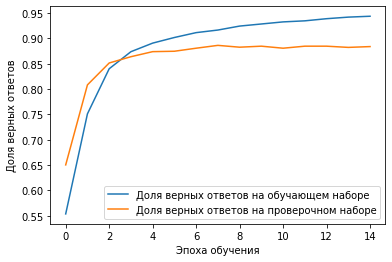

In [ ]:
plt.plot(history.history['accuracy'],
         label='Доля верных ответов на обучающем наборе')
plt.plot(history.history['val_accuracy'],
         label='Доля верных ответов на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.show()

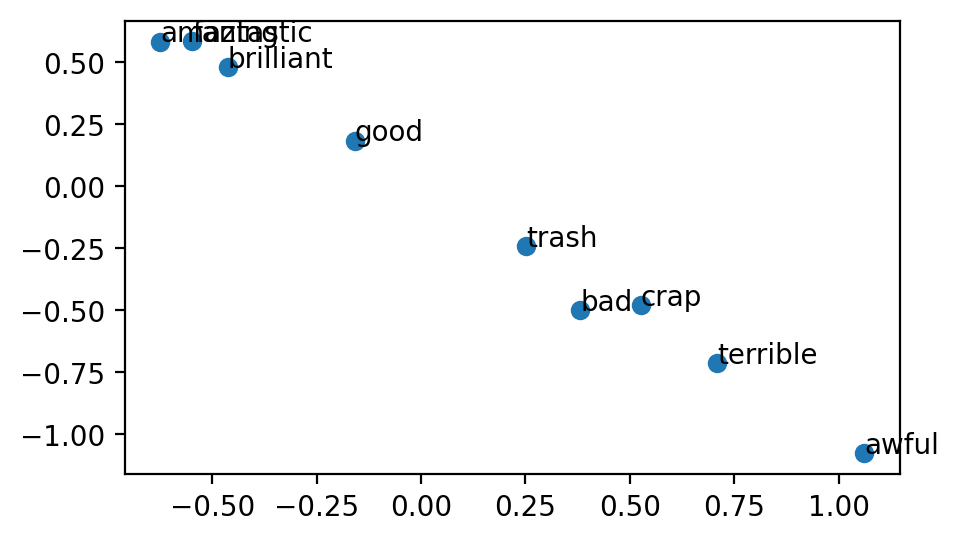

In [ ]:
embedding_matrix = model.layers[0].get_weights()[0]
embedding_matrix[:5]
word_index_org = imdb.get_word_index()

word_index = dict()
for word,number in word_index_org.items():
    word_index[word] = number + 3
word_index["<Заполнитель>"] = 0
word_index["<Начало последовательности>"] = 1
word_index["<Неизвестное слово>"] = 2
word_index["<Не используется>"] = 3

word = 'good'
word_number = word_index[word]

reverse_word_index = dict()
for key, value in word_index.items():
    reverse_word_index[value] = key

review = ['brilliant', 'fantastic', 'amazing', 'good',
          'bad', 'awful','crap', 'terrible', 'trash']
enc_review = []
for word in review:
    enc_review.append(word_index[word])

review_vectors = embedding_matrix[enc_review]

plt.figure(figsize=(5, 3), dpi=200, facecolor='w')
plt.rcParams['axes.facecolor'] = 'w'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.scatter(review_vectors[:,0], review_vectors[:,1])
for i, txt in enumerate(review):
    plt.annotate(txt, (review_vectors[i,0], review_vectors[i,1]), color='black')